# Least Squares and Computing Eigenvalues

**Source:** https://labs.acme.byu.edu/Volume1/LeastSquares_Eigenvalues/LeastSquares_Eigenvalues.html

This lab covers two topics: (1) least squares regression for fitting models to data, and (2) iterative eigenvalue algorithms — the QR algorithm and its shifted variant.

In [1]:
import numpy as np
from scipy import linalg as la
import matplotlib.pyplot as plt

## 1. Least Squares

For an overdetermined system $A\mathbf{x} \approx \mathbf{b}$ (more equations than unknowns), the **least squares solution** minimizes $\|A\mathbf{x} - \mathbf{b}\|_2$.

The solution satisfies the **normal equations**: $A^T A \mathbf{x} = A^T \mathbf{b}$.

Via QR: if $A = QR$, then $\mathbf{x} = R^{-1} Q^T \mathbf{b}$.

Line fit: y = 1.0000 + 2.0200*t


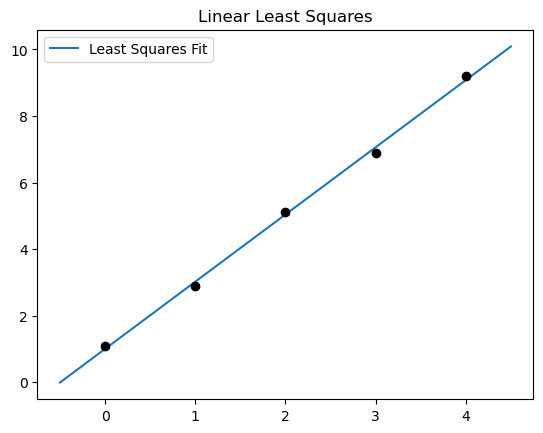

In [2]:
# Example: fit a line y = a + bt to data
t = np.array([0, 1, 2, 3, 4], dtype=float)
y = np.array([1.1, 2.9, 5.1, 6.9, 9.2])

A = np.column_stack([np.ones_like(t), t])   # design matrix
coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)

print(f"Line fit: y = {coeffs[0]:.4f} + {coeffs[1]:.4f}*t")

t_fine = np.linspace(-0.5, 4.5, 200)
plt.scatter(t, y, color='k', zorder=5)
plt.plot(t_fine, coeffs[0] + coeffs[1]*t_fine, label='Least Squares Fit')
plt.legend()
plt.title('Linear Least Squares')
plt.show()

## 2. The QR Algorithm for Eigenvalues

Repeatedly factor A = QR, then set A ← RQ. The diagonal of A converges to the eigenvalues.

**Wilkinson shift** accelerates convergence: shift by the eigenvalue of the bottom 2×2 submatrix closest to $a_{nn}$.

---

## Problem 1: Least Squares — Line and Ellipse Fitting

Fit a line to the data (year, earnings per share) and an ellipse to a set of 2D points.

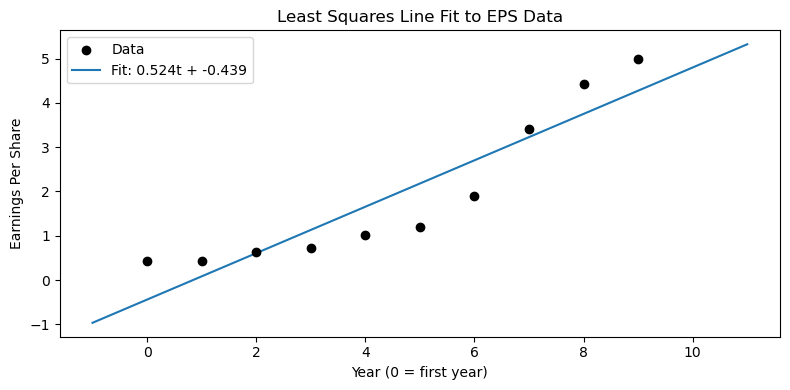

Slope: 0.5238, Intercept: -0.4389


In [3]:
def prob1():
    """Fit a line to year vs EPS data; return slope and intercept."""
    # EPS data: year index (0-9) and earnings per share
    year = np.arange(10, dtype=float)
    eps  = np.array([0.44, 0.44, 0.64, 0.72, 1.02, 1.20, 1.90, 3.40, 4.42, 5.00])
    
    A = np.column_stack([year, np.ones_like(year)])
    
    coeffs, *_ = np.linalg.lstsq(A, eps, rcond=None)
    slope, intercept = coeffs
    
    t = np.linspace(-1, 11, 200)
    plt.figure(figsize=(8, 4))
    plt.scatter(year, eps, color='k', zorder=5, label='Data')
    plt.plot(t, slope*t + intercept, label=f'Fit: {slope:.3f}t + {intercept:.3f}')
    plt.xlabel('Year (0 = first year)')
    plt.ylabel('Earnings Per Share')
    plt.legend()
    plt.title('Least Squares Line Fit to EPS Data')
    plt.tight_layout()
    plt.show()
    
    return slope, intercept

slope, intercept = prob1()
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}")

## Problem 2: Polynomial Fitting

Fit polynomials of degrees 1, 3, 6, and 9 to the same dataset. Compare their quality.

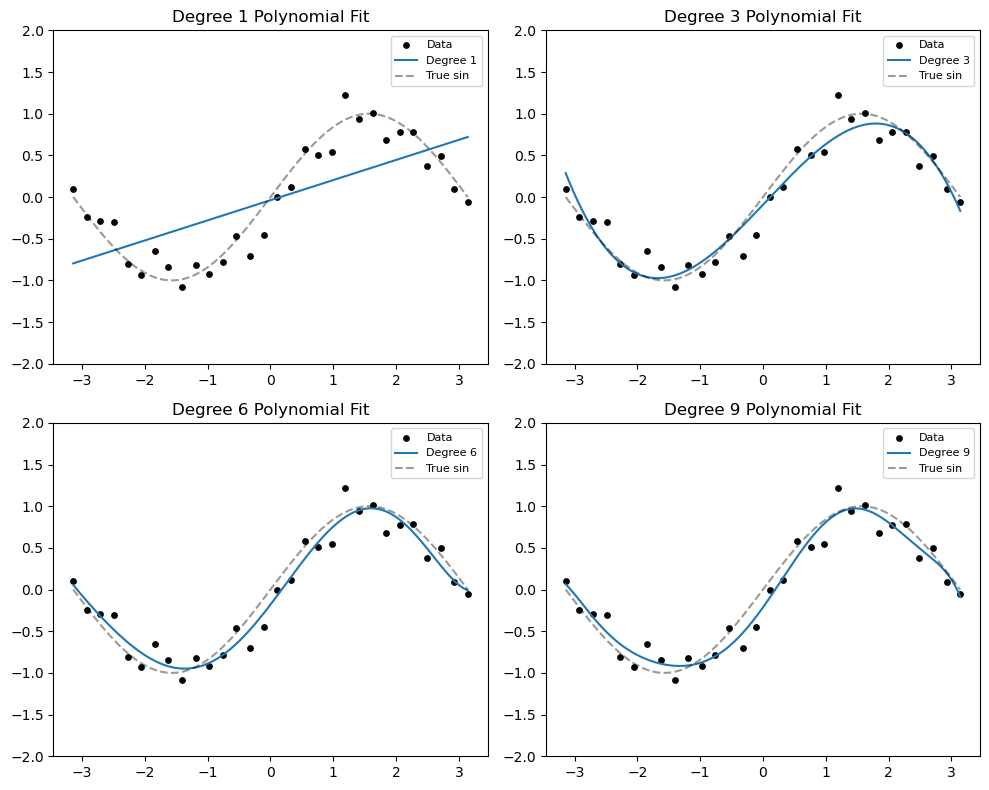

In [4]:
def prob2():
    """Fit polynomials of various degrees to noisy sin data."""
    np.random.seed(42)
    t = np.linspace(-np.pi, np.pi, 30)
    y = np.sin(t) + 0.2 * np.random.randn(30)
    
    t_fine = np.linspace(-np.pi, np.pi, 300)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    for ax, deg in zip(axes.flat, [1, 3, 6, 9]):
        A = np.vstack([t**k for k in range(deg + 1)]).T
        coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)
        A_fine = np.vstack([t_fine**k for k in range(deg + 1)]).T
        ax.scatter(t, y, s=15, color='k', label='Data')
        ax.plot(t_fine, A_fine @ coeffs, label=f'Degree {deg}')
        ax.plot(t_fine, np.sin(t_fine), 'k--', alpha=0.4, label='True sin')
        ax.set_ylim(-2, 2)
        
        ax.legend(fontsize=8)
        ax.set_title(f'Degree {deg} Polynomial Fit')
    
    plt.tight_layout()
    plt.show()

prob2()

## Problem 3: QR Algorithm (Basic)

Implement the basic QR iteration: repeatedly factor A = QR, then set A ← RQ.

In [5]:
def prob3(A, N=50, tol=1e-12):
    """Basic QR iteration for eigenvalues.
    
    Parameters
    ----------
    A   : real symmetric ndarray (n, n)
    N   : max iterations
    tol : convergence threshold on subdiagonal norms
    
    Returns
    -------
    eigenvalues : ndarray (n,) — diagonal after convergence
    """
    Ak = A.copy().astype(float)
    for _ in range(N):
        Q, R = la.qr(Ak)
        Ak = R @ Q
        if np.max(np.abs(np.tril(Ak, -1))) < tol:
            break
    return np.diag(Ak)



# Test on a symmetric matrix
A = np.array([[2., 1., 0.],
              [1., 3., 1.],
              [0., 1., 4.]])
eigs_qr  = np.sort(prob3(A))
eigs_ref = np.sort(np.linalg.eigvalsh(A))
print("QR algorithm eigenvalues:", eigs_qr)
print("True eigenvalues:         ", eigs_ref)
print("Max error:", np.max(np.abs(eigs_qr - eigs_ref)))

QR algorithm eigenvalues: [1.26794919 3.         4.73205081]
True eigenvalues:          [1.26794919 3.         4.73205081]
Max error: 1.7763568394002505e-15


## Problem 4: Hessenberg Reduction + QR with Shifts

Reduce A to upper Hessenberg form first (O(n³) once), then apply QR iteration with Wilkinson shifts for fast convergence.

In [6]:
def wilkinson_shift(a, b, c):
    """Wilkinson shift: eigenvalue of [[a,b],[b,c]] closest to c."""
    delta = (a - c) / 2
    sign  = 1 if delta >= 0 else -1
    return c - sign * b**2 / (abs(delta) + np.sqrt(delta**2 + b**2))


def prob4(A, N=200, tol=1e-12):
    """QR algorithm with Hessenberg reduction and Wilkinson shifts.
    
    Returns eigenvalues (real, for symmetric input).
    """
    H = la.hessenberg(A).astype(float)
    n = H.shape[0]
    
    eigenvalues = []
    
    while n > 1:
        iters = 0
        while abs(H[n-1, n-2]) > tol and iters < N:
            shift = wilkinson_shift(H[n-2, n-2], H[n-1, n-2], H[n-1, n-1])
            Q, R = la.qr(H[:n, :n] - shift * np.eye(n))
            H[:n, :n] = R @ Q + shift * np.eye(n)
            iters += 1
        eigenvalues.append(H[n-1, n-1])
        H = H[:n-1, :n-1]
        n -= 1
    eigenvalues.append(H[0, 0])
    return np.array(eigenvalues)


np.random.seed(0)
B = np.random.randn(6, 6)
B = B + B.T  # make symmetric

eigs_shifted = np.sort(prob4(B))
eigs_true    = np.sort(np.linalg.eigvalsh(B))
print("Shifted QR eigenvalues:", eigs_shifted)
print("True eigenvalues:       ", eigs_true)
print("Max error:", np.max(np.abs(eigs_shifted - eigs_true)))

Shifted QR eigenvalues: [-4.19363571 -3.29961981  1.1868035   1.98666124  4.46448202  8.65391906]
True eigenvalues:        [-4.19363571 -3.29961981  1.1868035   1.98666124  4.46448202  8.65391906]
Max error: 1.0658141036401503e-14


## Problem 5: Convergence Rate Comparison

Compare basic QR vs shifted QR — show how quickly the subdiagonal norm converges.

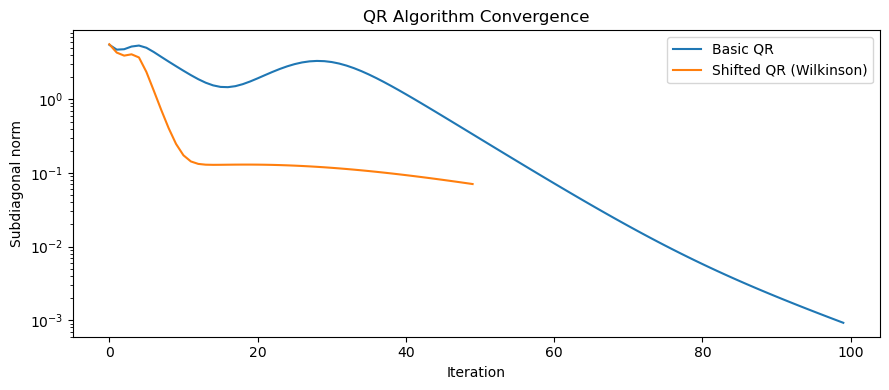

In [7]:
def qr_subdiag_norms(A, N=100):
    """Track subdiagonal norms for basic QR iteration."""
    Ak = la.hessenberg(A).astype(float)
    norms = []
    for _ in range(N):
        Q, R = la.qr(Ak)
        Ak = R @ Q
        norms.append(np.linalg.norm(np.tril(Ak, -1)))
    return norms


def qr_shifted_subdiag_norms(A, N=50):
    """Track subdiagonal norms for shifted QR iteration."""
    Ak = la.hessenberg(A).astype(float)
    n  = Ak.shape[0]
    norms = []
    
    for _ in range(N):
        shift = wilkinson_shift(Ak[n-2, n-2], Ak[n-1, n-2], Ak[n-1, n-1])
        Q, R = la.qr(Ak - shift * np.eye(n))
        Ak = R @ Q + shift * np.eye(n)
        norms.append(np.linalg.norm(np.tril(Ak, -1)))
    return norms


np.random.seed(1)
C = np.random.randn(8, 8)
C = C + C.T

basic_norms   = qr_subdiag_norms(C)
shifted_norms = qr_shifted_subdiag_norms(C)

plt.figure(figsize=(9, 4))
plt.semilogy(basic_norms,   label='Basic QR')
plt.semilogy(shifted_norms, label='Shifted QR (Wilkinson)')
plt.xlabel('Iteration')
plt.ylabel('Subdiagonal norm')
plt.title('QR Algorithm Convergence')
plt.legend()
plt.tight_layout()
plt.show()